**#Bahraini Currency Recognition with Deep Learning**¶

*The aim is to classify a picture of Bahraini currency into its correct class. *bold tex

## 1. Data Collection

In [8]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import set_random_seed

In [9]:
seed = 100

random.seed(seed)
np.random.seed(seed)
set_random_seed(seed)

In [10]:
data_path = "/content/Currency"
image_size = 64

class_names = ["0.05", "0.100", "0.25", "0.5 BD", "0.50",
               "1BD", "5 BD", "10 BD", "20 BD"]
class_names

['0.05', '0.100', '0.25', '0.5 BD', '0.50', '1BD', '5 BD', '10 BD', '20 BD']

In [11]:
#Dataset path
import os

os.listdir("/content")

['.config', 'Currency.zip', 'sample_data']

In [12]:
!unzip -q -o "/content/Currency.zip" -d "/content/"

In [13]:
os.listdir("/content/Currency")

['20 BD', '1BD', '0.05', '10 BD', '0.50', '0.100', '5 BD', '0.25', '0.5 BD']

In [14]:
images = []
labels = []

for label, class_name in enumerate(class_names):
    for folder_name in ["Train", "Test"]:
        folder = os.path.join(data_path, class_name, folder_name)

        for file_name in os.listdir(folder):
            image_path = os.path.join(folder, file_name)

            if os.path.isfile(image_path):
                image = Image.open(image_path).convert("RGB")
                image = image.resize((image_size, image_size))

                images.append(np.array(image))
                labels.append(label)

In [15]:
X = np.array(images)
y = np.array(labels)

X.shape, y.shape

((474, 64, 64, 3), (474,))

In [16]:
image_counts = pd.Series(y).value_counts().sort_index()
image_counts.index = class_names
image_counts

,count
0.05,50
0.100,45
0.25,51
0.5 BD,48
0.50,50
1BD,62
5 BD,63
10 BD,50
20 BD,55


#2. Preprocessing



In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [18]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((379, 64, 64, 3), (95, 64, 64, 3), (379,), (95,))

In [19]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train)

x_train.shape, x_val.shape, x_test.shape

((303, 64, 64, 3), (76, 64, 64, 3), (95, 64, 64, 3))

### Data Augmentation

In [20]:
augmentation = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2])

In [21]:
new_images, new_labels = next(
    augmentation.flow(
        x_train,
        y_train,
        batch_size=len(x_train),
        shuffle=False,
        seed=seed))

x_train = np.concatenate([x_train, new_images])
y_train = np.concatenate([y_train, new_labels])

### Normalize Pixel Values

In [22]:
x_train_scaled = x_train / 255
x_val_scaled = x_val / 255
x_test_scaled = x_test / 255

# 3. Model Training (Classification)

In [23]:
model = Sequential()
model.add(Flatten(input_shape=(image_size, image_size, 3)))

model.add(Dense(256, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))

model.add(Dense(len(class_names), activation="softmax"))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,721 (12.16 MB)

 Trainable params: 3,187,721 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["acc"])

## Class Weights

In [25]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train)

class_weight_dictionary = dict(enumerate(class_weights))
class_weight_dictionary

{0: np.float64(1.0520833333333333),
 1: np.float64(1.160919540229885),
 2: np.float64(1.02020202020202),
 3: np.float64(1.1222222222222222),
 4: np.float64(1.0520833333333333),
 5: np.float64(0.8416666666666667),
 6: np.float64(0.8416666666666667),
 7: np.float64(1.0520833333333333),
 8: np.float64(0.9619047619047619)}

## Early Stopping

In [26]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True)

In [27]:
history = model.fit(
    x_train_scaled,
    y_train,
    validation_data=(x_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    class_weight=class_weight_dictionary)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - acc: 0.1106 - loss: 4.2525 - val_acc: 0.1053 - val_loss: 2.3589
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - acc: 0.1056 - loss: 2.8424 - val_acc: 0.0921 - val_loss: 2.2499
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - acc: 0.1254 - loss: 2.3836 - val_acc: 0.0921 - val_loss: 2.3049
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - acc: 0.1073 - loss: 2.2579 - val_acc: 0.0789 - val_loss: 2.2070
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.1221 - loss: 2.2113 - val_acc: 0.1579 - val_loss: 2.1881
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - acc: 0.1386 - loss: 2.1747 - val_acc: 0.1316 - val_loss: 2.1730
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - acc: 0.1287 - loss: 2.1832 - val_acc: 0.1579 - val_loss: 2.1720
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - acc: 0.1271 - loss: 2.1807 - val_acc: 0.0658 - val_loss: 2.1791
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - a

## Training History

In [28]:
history_df = pd.DataFrame(history.history)
history_df.tail()

,acc,loss,val_acc,val_loss
52,0.295380,1.764572,0.355263,1.825005
53,0.344884,1.664432,0.342105,1.843359
54,0.320132,1.704113,0.276316,2.054731
55,0.282178,1.777949,0.368421,1.760159
56,0.343234,1.611398,0.434211,1.750171


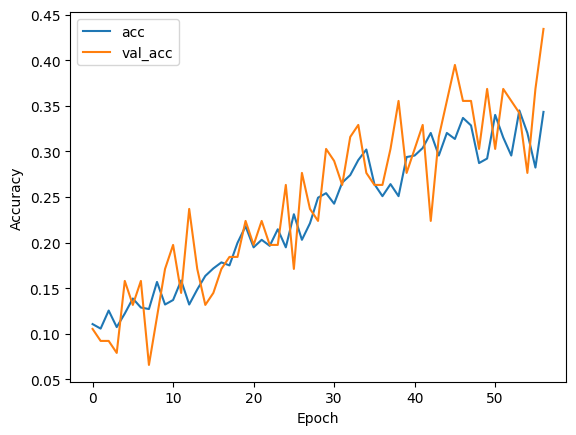

In [29]:
history_df[["acc", "val_acc"]].plot()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

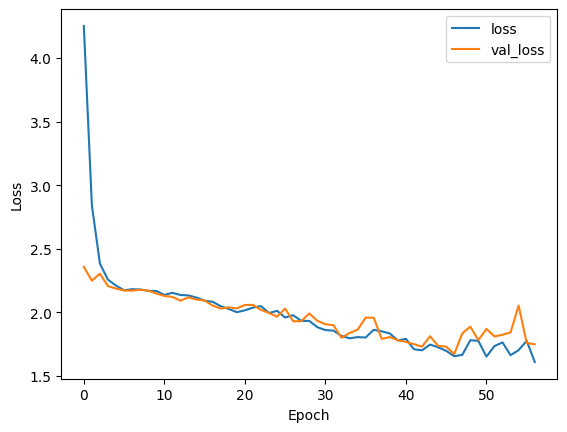

In [30]:
history_df[["loss", "val_loss"]].plot()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 4. Model Evaluation

In [31]:
y_pred = model.predict(x_test_scaled)
y_pred_label = y_pred.argmax(axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


##Accuracy

In [32]:
accuracy_score(y_test, y_pred_label)

0.3263157894736842

##Precision, Recall and Per-Class Performance

In [33]:
print(classification_report(
    y_test,
    y_pred_label,
    labels=range(len(class_names)),
    target_names=class_names,
    zero_division=0))

              precision    recall  f1-score   support

        0.05       0.64      0.70      0.67        10
       0.100       0.00      0.00      0.00         9
        0.25       0.00      0.00      0.00        10
      0.5 BD       0.44      0.80      0.57        10
        0.50       0.46      0.60      0.52        10
         1BD       0.18      0.42      0.25        12
        5 BD       0.33      0.08      0.12        13
       10 BD       0.50      0.10      0.17        10
       20 BD       0.33      0.27      0.30        11

    accuracy                           0.33        95
   macro avg       0.32      0.33      0.29        95
weighted avg       0.32      0.33      0.29        95



# Confusion Matrix

In [34]:
conf_matrix = confusion_matrix(
    y_test,
    y_pred_label,
    labels=range(len(class_names)))

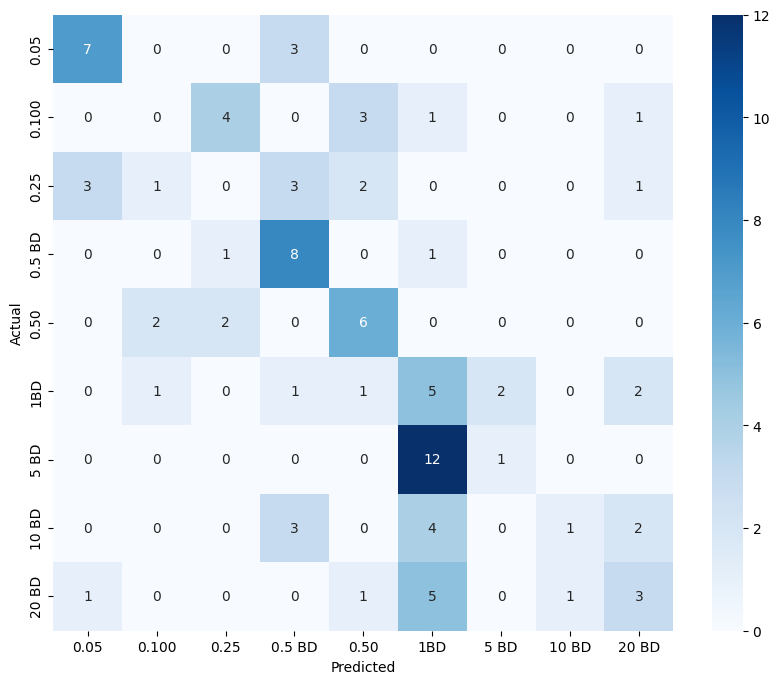

In [35]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Blues",
    fmt="g",
    xticklabels=class_names,
    yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Error Analysis

In [36]:
idx = np.where(y_test != y_pred_label)[0]
idx

array([ 1,  2,  3,  4,  6,  7,  9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22,
       23, 24, 27, 28, 29, 30, 33, 34, 35, 38, 39, 40, 41, 43, 44, 45, 46,
       49, 51, 53, 54, 55, 56, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 71,
       72, 74, 75, 76, 78, 80, 81, 83, 84, 85, 86, 89, 94])

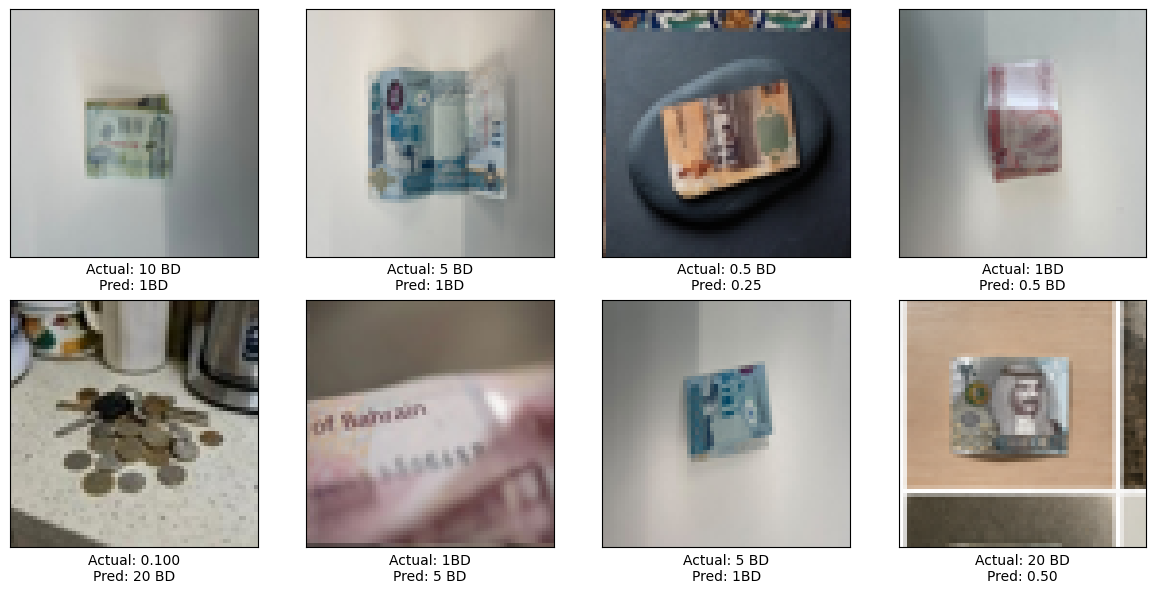

In [37]:
plt.figure(figsize=(12, 6))

for i in range(min(8, len(idx))):
    plt.subplot(2, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[idx[i]])
    plt.xlabel(
        f"Actual: {class_names[y_test[idx[i]]]}\n"
        f"Pred: {class_names[y_pred_label[idx[i]]]}")

plt.tight_layout()
plt.show()

# 5. Model Deployment (Streamlit)

In [38]:
model.save("currency_0model.keras")

# 6. Key Questions

In [40]:
confused_matrix = conf_matrix.copy()
np.fill_diagonal(confused_matrix, 0)

actual_class, predicted_class = np.unravel_index(
    confused_matrix.argmax(), confused_matrix.shape)

print("Most confused actual currency:", class_names[actual_class])
print("Most common wrong prediction:", class_names[predicted_class])

Most confused actual currency: 5 BD
Most common wrong prediction: 1BD


1. **Which currency is most confusing?** The output above identifies the actual currency that produced the most common wrong prediction.

2. **Are similar-looking notes misclassified?** Compare the two currencies printed above and review their incorrect images in the error-analysis section. Similar colours, shapes or designs can make them harder to separate.

3. **Does background affect performance?** The incorrect images should be checked for hands, patterned surfaces, shadows and distant currency. If these backgrounds appear often among the errors, the background is affecting performance.

# 8. Final Reflection

1. **Why did classification work well initially?** It worked well because each image mainly contained one currency and each image had one clear class label.

2. **What problems did object detection solve?** Object detection would locate each currency separately and could handle more than one note or coin in the same image.

3. **Which approach is more suitable for real-world deployment?** Classification is suitable when the user shows one currency at a time. Object detection is more suitable when several currencies may appear together.

4. **How would you improve the system further?** Collect at least 50 different original images for every class, add more unseen backgrounds and lighting conditions, and test the model using more new mobile-phone photos.